# Airport Traffic Analysis And Forecasting

## **San Francisco Airport (SFO) traffic analysis**

San Francisco International Airport (IATA code: SFO) is located south of San Francisco downtown and it’s a major West Coast air transportation hub. It serves both domestic and international (also trans-Pacific) flights. It's equipped with 4 asphalt runways – two perpendicular pairs. This airport is one of the main hubs for the United Airline which generates relatively a big chunk of the airport's traffic


---
**EDA Highlights**
* Passengers traffic **steadily grows** from 2005 through 2018
* **The highest number** of passengers is reported so far is in August 2017: **5 497 000** people.
* There is a visible **peak in** the traffic during the **holiday period**
* Most of the flights are **domestic**
* Most of the flights are operated by **narrow body aircraft** (e.g. Boeing 737, Airbus 320)
* The biggest share in a traffic generation has the **United Airlines** (over 57%)
* SARIMAX model predicts that **in 2022** the airport's traffic will be between **5 and 7 million** passengers with confidence intervals between 3.5-8.5 million


In [171]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # data visualisation
import matplotlib.pyplot as plt # data visualisation
import datetime as dt # working with time data

import warnings  
warnings.filterwarnings('ignore')


### 1) EDA
Importing time series data

In [172]:
df = pd.read_csv("air-traffic-passenger-statistics.csv")
df1 = df.copy()
df1.head()

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090


In [173]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18885 entries, 0 to 18884
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              18885 non-null  int64 
 1   Operating Airline            18885 non-null  object
 2   Operating Airline IATA Code  18822 non-null  object
 3   Published Airline            18885 non-null  object
 4   Published Airline IATA Code  18822 non-null  object
 5   GEO Summary                  18885 non-null  object
 6   GEO Region                   18885 non-null  object
 7   Activity Type Code           18885 non-null  object
 8   Price Category Code          18885 non-null  object
 9   Terminal                     18885 non-null  object
 10  Boarding Area                18885 non-null  object
 11  Passenger Count              18885 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 1.7+ MB


In [176]:
import pandas as pd

counts = df.dtypes.value_counts()

overview = pd.DataFrame({
    "Metric": ["Total Rows", "Total Features", "Text Columns", "Numeric Columns"],
    "Value": [
        df.shape[0],
        df.shape[1],
        counts.get('object', 0),
        counts.get('int64', 0) + counts.get('float64', 0)
    ]
})

print(overview)

            Metric  Value
0       Total Rows  18885
1   Total Features     12
2     Text Columns     10
3  Numeric Columns      0


### Checking missing data.

In [13]:
nulls = df1.isnull().sum().to_frame().sort_values(by=0, ascending = False)
nulls.columns = ["Missing values"]
nulls[nulls['Missing values'] != 0]

,Missing values
Operating Airline IATA Code,63
Published Airline IATA Code,63


Only 2 columns contain missing information. However, these columns are not relevant for this analysis as these are just IATA Airline Codes. These are 2-letter codes and most of the airlines have such a code

In [14]:
df1.loc[:,"Activity Period"] = pd.to_datetime(df1.loc[:,"Activity Period"].astype(str), format="%Y%m")
df1.loc[:,"Year"] = df1["Activity Period"].dt.year
df1.loc[:,"Month"] = df1["Activity Period"].dt.month

Checking what time range is reported.

In [28]:
import numpy as np

# Calculate the start, end, and difference
time_begin = df1["Activity Period"].min()
time_end = df1["Activity Period"].max()
time_range = time_end - time_begin

print(f"First date: {time_begin.strftime('%Y-%m-%d')}")
print(f"Last date:  {time_end.strftime('%Y-%m-%d')}")
print(f"Time range in days: {time_range.days}")

# Calculate months (using 30.44 days as an average month for accuracy)
time_range_months = (time_range / np.timedelta64(1, 'D')) / 30.44
print(f"Time range in months: {time_range_months:.2f}")

First date: 2005-07-01
Last date:  2018-06-01
Time range in days: 4718
Time range in months: 154.99


### 1.2 Airline traffic generation

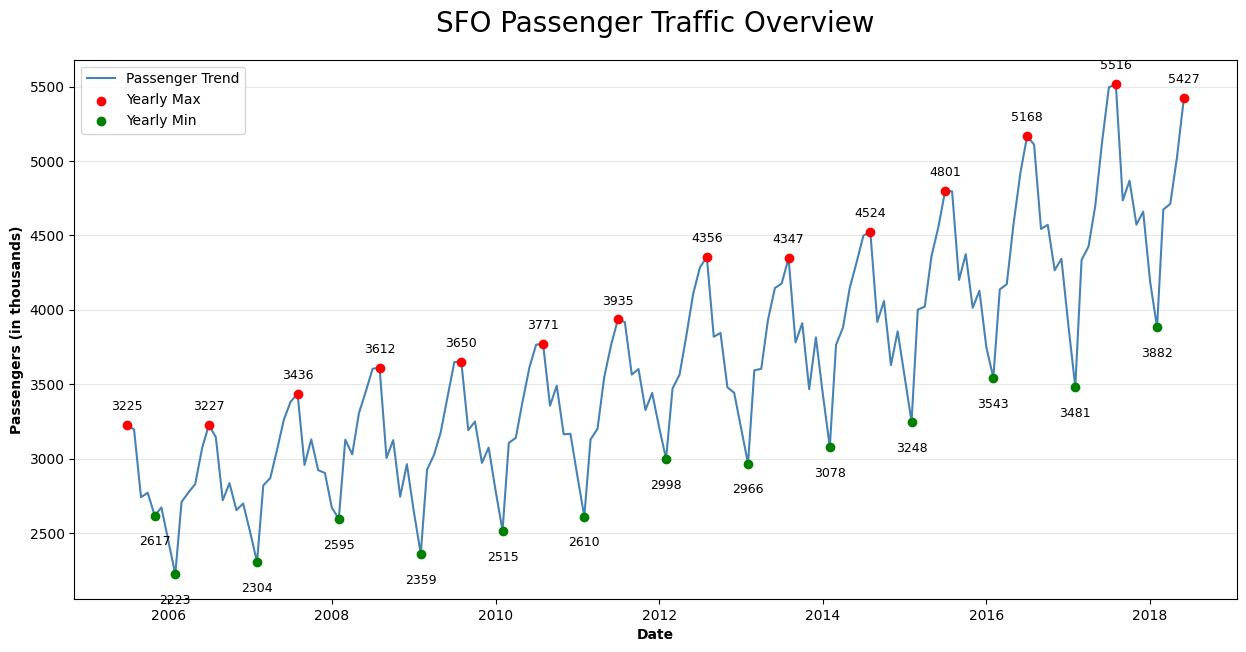

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare Data
df1_yr = df1.groupby("Activity Period")["Passenger Count"].sum() / 1000

# Find Highs and Lows per year
df1_maxs = df1_yr.groupby(df1_yr.index.year).transform('max')
df1_mins = df1_yr.groupby(df1_yr.index.year).transform('min')

high_points = df1_yr[df1_yr == df1_maxs]
low_points = df1_yr[df1_yr == df1_mins]

# Plotting
plt.figure(figsize=(15, 7))
sns.lineplot(x=df1_yr.index, y=df1_yr.values, color='steelblue', label='Passenger Trend')

# Mark Max (Red) and Min (Green)
plt.scatter(high_points.index, high_points.values, color='red', label='Yearly Max', zorder=3)
plt.scatter(low_points.index, low_points.values, color='green', label='Yearly Min', zorder=3)

# Simple Annotation Loop
for date, val in high_points.items():
    plt.text(date, val + 100, f'{int(val)}', ha='center', color='black', fontsize=9)

for date, val in low_points.items():
    plt.text(date, val - 200, f'{int(val)}', ha='center', color='black', fontsize=9)

# Labels
plt.title("SFO Passenger Traffic Overview", size=20, pad=20)
plt.ylabel("Passengers (in thousands)", fontweight="bold")
plt.xlabel("Date", fontweight="bold")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

The number of passengers is generally increasing (trend) with a clear seasonal pattern with a period of about one year. 

The traffic peak is around summertime while the lowest traffic is during wintertime at the beginning of the year.

The heatmap below shows what amount of traffic various airlines generated through the years (in thousands).

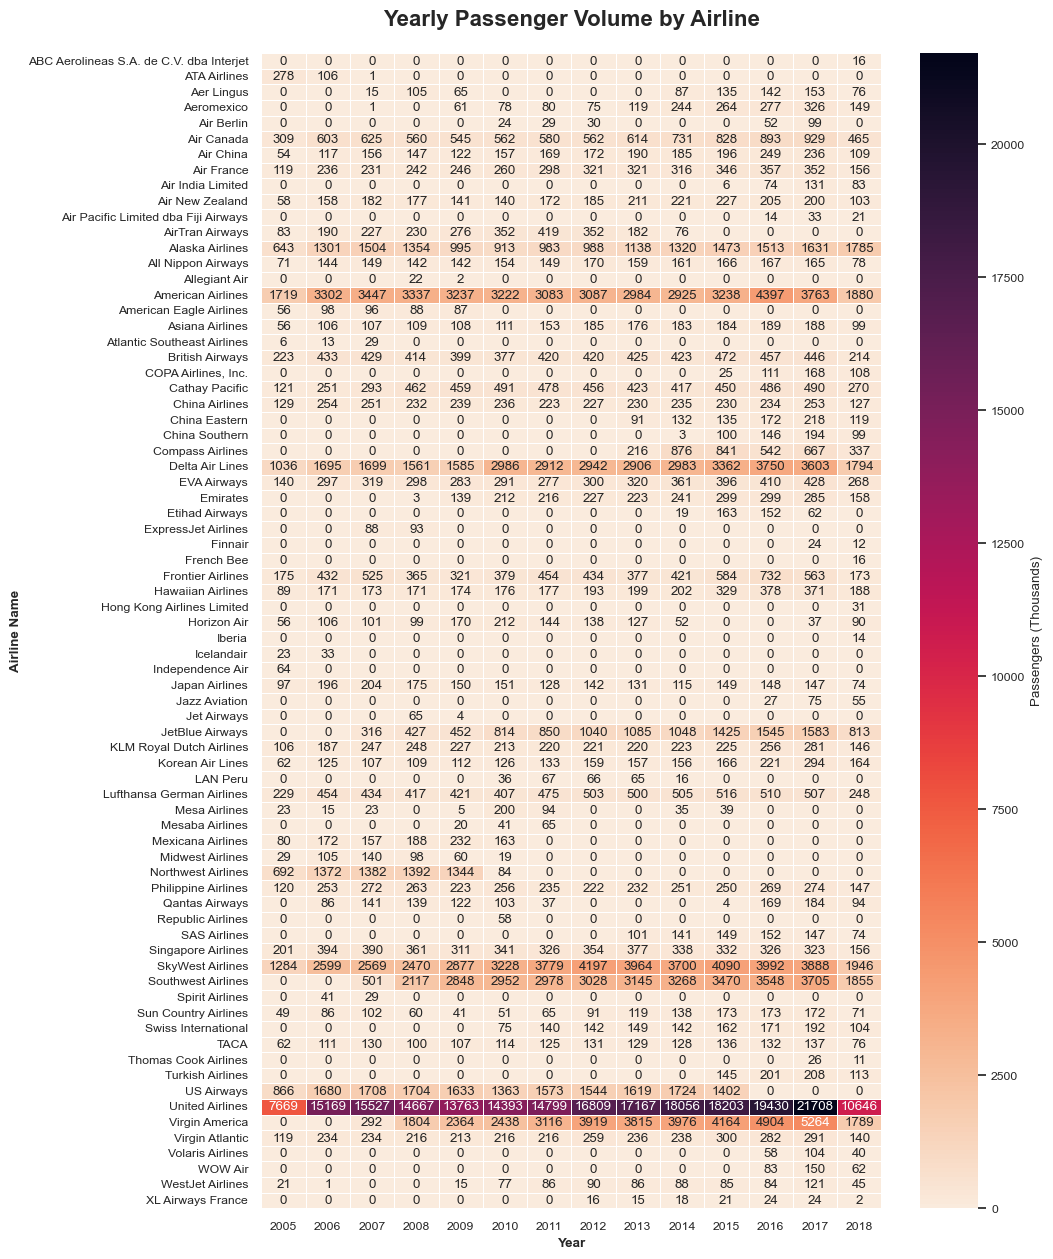

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare Data & Pivot
# Merge "United Airlines - Pre 07/01/2013" into "United Airlines" before pivoting
df1.replace("United Airlines - Pre 07/01/2013", "United Airlines", inplace=True)

pivot_1 = df1.pivot_table(
    values="Passenger Count", 
    index="Operating Airline", 
    columns="Year", 
    aggfunc="sum"
).divide(1000).fillna(0)

# Filter out small airlines (Total passengers across all years < 13k)
pivot_1 = pivot_1[pivot_1.sum(axis=1) >= 13]

# Plotting the Heatmap
plt.figure(figsize=(10, 15))
sns.set(font_scale=0.8)

sns.heatmap(
    pivot_1, 
    annot=True, 
    fmt=".0f", 
    linewidths=.5, 
    cmap="rocket_r", 
    cbar_kws={'label': 'Passengers (Thousands)'}
)

plt.title("Yearly Passenger Volume by Airline", fontsize=16, fontweight="bold", pad=20)
plt.ylabel("Airline Name", fontweight="bold")
plt.xlabel("Year", fontweight="bold")

plt.show()

which airlines generate the most of the traffic? 

Average number of passengers per airline each year and calculating its share in the total traffic.

In [34]:
# Get the average passengers per year for each airline
avg_airline = pivot_1.mean(axis=1)

# Grab the Top 5, scale back to actual numbers (thousands * 1000)
top_5 = avg_airline.nlargest(5).to_frame(name="Avg Yearly Passengers")
top_5 = (top_5 * 1000).astype(int)

# Calculate % share of just the top 5
total_top_5 = top_5["Avg Yearly Passengers"].sum()
top_5["Share %"] = (top_5["Avg Yearly Passengers"] / total_top_5 * 100).round(1)

top_5

,Avg Yearly Passengers,Share %
Operating Airline,,
United Airlines,15571737,57.5
SkyWest Airlines,3184454,11.8
American Airlines,3115884,11.5
Virgin America,2703137,10.0
Delta Air Lines,2486702,9.2


### 1.3 TOP 5 BIGGEST AIRLINES

**1. United Airlines**

**2. SkyWest Airlines**

**3. American Airlines**

**4. Virgin America**

**5. Delta Airlines**



### 1.4 Passenger traffic overview

- Below there is a heatmap showing the number of passengers in each month for years 2005-2018 (in thousands). 
- We can see a peak in traffic around June-August.
- The highest number reported so far is in August 2017: 5497000 passengers.
- Such a peak indicate a holiday period.

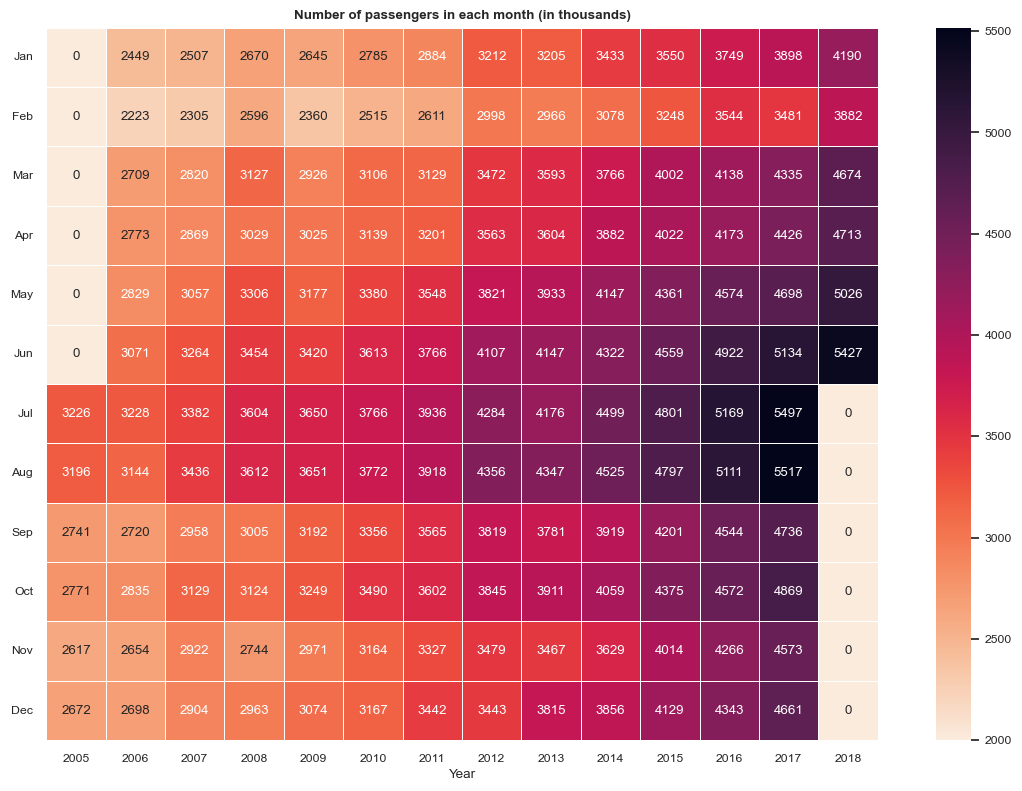

In [54]:
# 1. Group, scale, and explicitly cast to integer to fix the ValueError
df1_month_yr = df1.groupby(["Year","Month"])["Passenger Count"].sum().divide(1000).round().astype(int)
df1_month_yr = df1_month_yr.reset_index()

# 2. Create the pivot table
pivot_2 = df1_month_yr.pivot_table(values="Passenger Count", index="Month", columns="Year", fill_value=0)
pivot_2.index = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# 3. Setup the visual style
sns.set(font_scale=0.8)
fig = plt.figure(figsize=(12,8))

# 4. Generate the heatmap
g = sns.heatmap(pivot_2, annot=True, linewidths=.5, fmt=".0f", square=True, vmin=2000, cmap=sns.cm.rocket_r)

# 5. Labels and display
g.set_title("Number of passengers in each month (in thousands)", fontweight="bold")
g.set_yticklabels(g.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

The line plot below shows the share of traffic being generated by each geographic region (excluding North America). The biggest share have Asia and Europe.

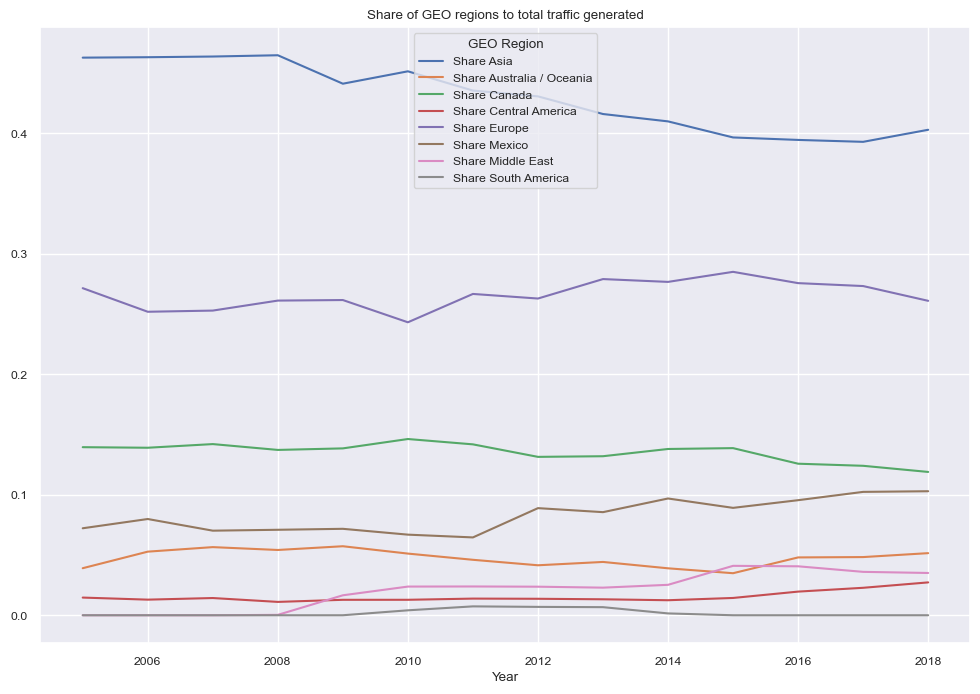

In [60]:
# market share of international travel regions - SHARE = REGION PASSENGERS / TOTAL INTERNATIONAL PASSENGERS

x1 = df1.groupby(["Year","GEO Region"])["Passenger Count"].sum()
x1 = x1.reset_index()

pivot_5 = x1.pivot_table(values="Passenger Count",index="Year",columns="GEO Region", fill_value=0)
pivot_5 = pivot_5.drop("US",axis=1)
pivot_5["Total"] = pivot_5.sum(axis=1)

for col in pivot_5.columns[:-1]:
        pivot_5["Share " + str(col)]=pivot_5[col]/pivot_5["Total"]

ratios_5 = pivot_5.iloc[:,-8:]
ratios_5.plot(figsize=(12,8), title="Share of GEO regions to total traffic generated")
plt.show()

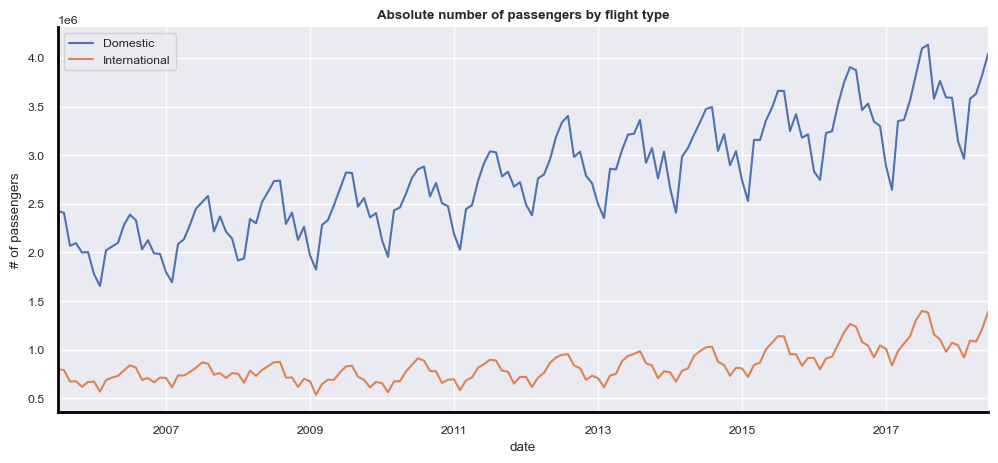

In [62]:
# Volume of travel

TS2 = df1[df1["GEO Summary"]=="Domestic"].groupby("Activity Period")["Passenger Count"].sum()
TS3 = df1[df1["GEO Summary"]=="International"].groupby("Activity Period")["Passenger Count"].sum()
TS = pd.concat([TS2,TS3],axis=1)
TS.columns=["Domestic","International"]

ax = TS.plot(figsize=(12,5))
ax.set_title("Absolute number of passengers by flight type", fontweight="bold")
ax.set_xlabel('date')
ax.set_ylabel('# of passengers')
for loc in ['bottom', 'left']:
    ax.spines[loc].set_visible(True)
    ax.spines[loc].set_linewidth(2)
    ax.spines[loc].set_color('black')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()

## 2. Time Series Forecasting

## 2.1 SARIMAX - Seasonal AutoRegressive Integrated Moving Average with eXogenous factors

#### Why we are using it for SFO Passenger Data
The SFO dataset is perfect for SARIMAX because it follows three specific patterns:

Yearly Habits (Seasonality): Travel isn't random. Every year, we see a "spike" in the summer and a "dip" in the winter. SARIMAX is designed to "remember" these yearly cycles.

Long-Term Growth (Trend): Over many years, the number of people flying generally goes up as technology and the economy grow. SARIMAX can track this steady climb.

Outside Factors (Exogenous): Sometimes, things outside of the airport affect travel—like a sudden change in ticket prices or a global event. The "X" in SARIMAX allows us to add these extra facts to make the prediction more accurate.

#### Summary: When is SARIMAX the best choice?
We use SARIMAX when our data is not "flat." It is the best choice when:

There is a clear pattern that repeats (like every Monday or every December).

The numbers are consistently growing or shrinking over time.

We have extra information (like holidays or fuel costs) that might help explain why passenger numbers change.

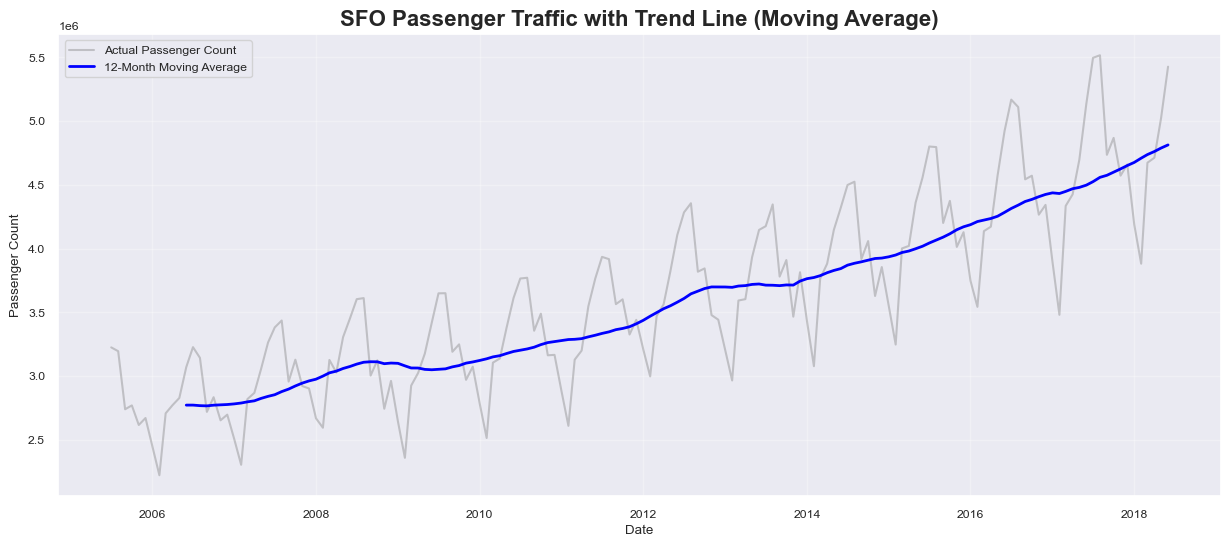

In [82]:
# Calculate the 12-month moving average
# This averages the last 12 months to smooth out the "ups and downs"
TS1['12-Month MA'] = TS1['Passenger Count'].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(15, 6))

# Plot the actual data
plt.plot(TS1.index, TS1['Passenger Count'], label='Actual Passenger Count', alpha=0.4, color='gray')

# Plot the Moving Average (The smooth trend line)
plt.plot(TS1.index, TS1['12-Month MA'], label='12-Month Moving Average', color='blue', linewidth=2)

plt.title("SFO Passenger Traffic with Trend Line (Moving Average)", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Passenger Count")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

The plot above shows overall traffic on the airport over time. It appears like it has a linear character but a proper decomposition is required.

The **Augmented Dickey-Fuller** test can be used to test for stationarity of our time series. The null hypothesis of the test is that the time series is not stationary (has some time-dependent structure).
* **Null Hypothesis (H0):** if failed to be rejected (high p-value) means it is non-stationary
* **Null Hypothesis (H1):** if H0 is rejected (low p-value) means it is stationary

We use the Augmented Dickey-Fuller (ADF) test to determine if our passenger data is stationary. If the test returns a high p-value, it confirms that our data has a trend (non-stationary) and requires 'differencing'—a process where we subtract values to flatten the trend—before we can accurately apply the SARIMAX model.

In [70]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(TS1["Passenger Count"])
print('ADF Statistic: %f' % results[0])
print('p-value: %f' % results[1])

ADF Statistic: 1.133106
p-value: 0.995489


P-value is 0.99 (we don't reject H0) - time series is not stationary. Data above 0.05 means non stationary

To better understand the time series behaviour, decompose it into 3 main components: 
* trend
* seasonality
* residuals

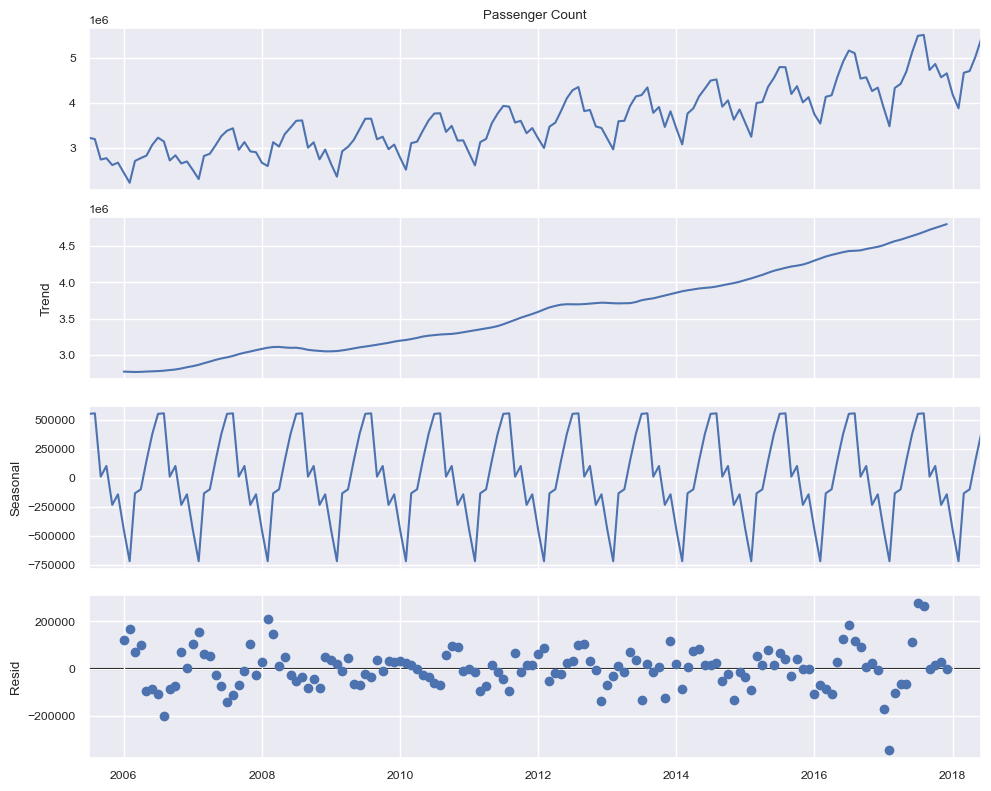

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Clean up the data and ensure it is a "Series" (not a DataFrame)
# used .iloc[:, 0] to grab only the first column of data
ts_series = TS1.iloc[:, 0].interpolate(method='linear').ffill().bfill()

# Set the frequency explicitly (12 for Monthly data)
# This prevents the "Index" error by providing a clean, single-column series
decomposed_add = seasonal_decompose(ts_series, model="additive", period=12)

# Plotting
plt.rcParams['figure.figsize'] = 10, 8
decomposed_add.plot()
plt.show()

The model seems to have a 12-month seasonal trend

In order to stationarize time series and to ARMA model I will transform this time series by taking the 1-month difference.


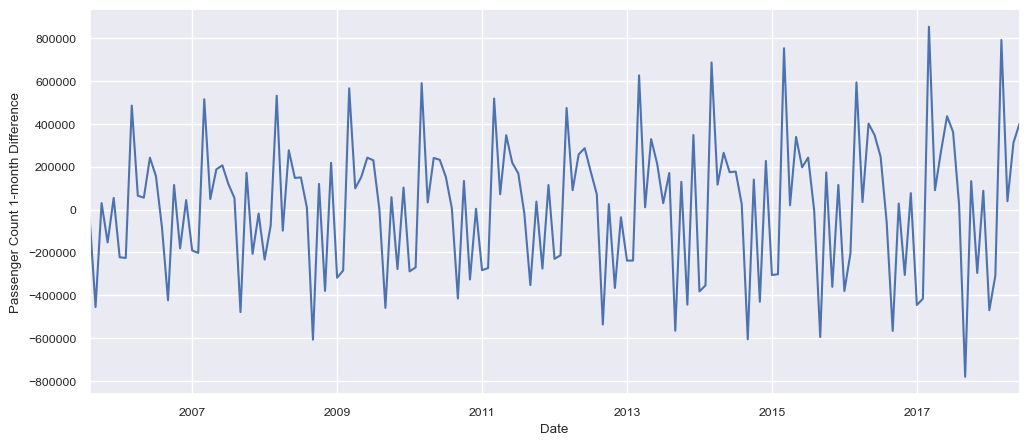

In [79]:
TS1_diff = TS1.diff().dropna()

plt.figure(figsize=(12,5))
ax = TS1_diff["Passenger Count"].plot()
ax.set_xlabel("Date")
ax.set_ylabel("Passenger Count 1-month Difference")
plt.grid(True)
plt.show()

In [84]:
results = adfuller(TS1_diff["Passenger Count"])
print('ADF Statistic: %f' % results[0])
print("P-value of a test is: {}".format(results[1]))

ADF Statistic: -2.950493
P-value of a test is: 0.039783614803845214


The p-value of 0.0397 is small enough to reject the null hipothesis that the time series is non-stationary.

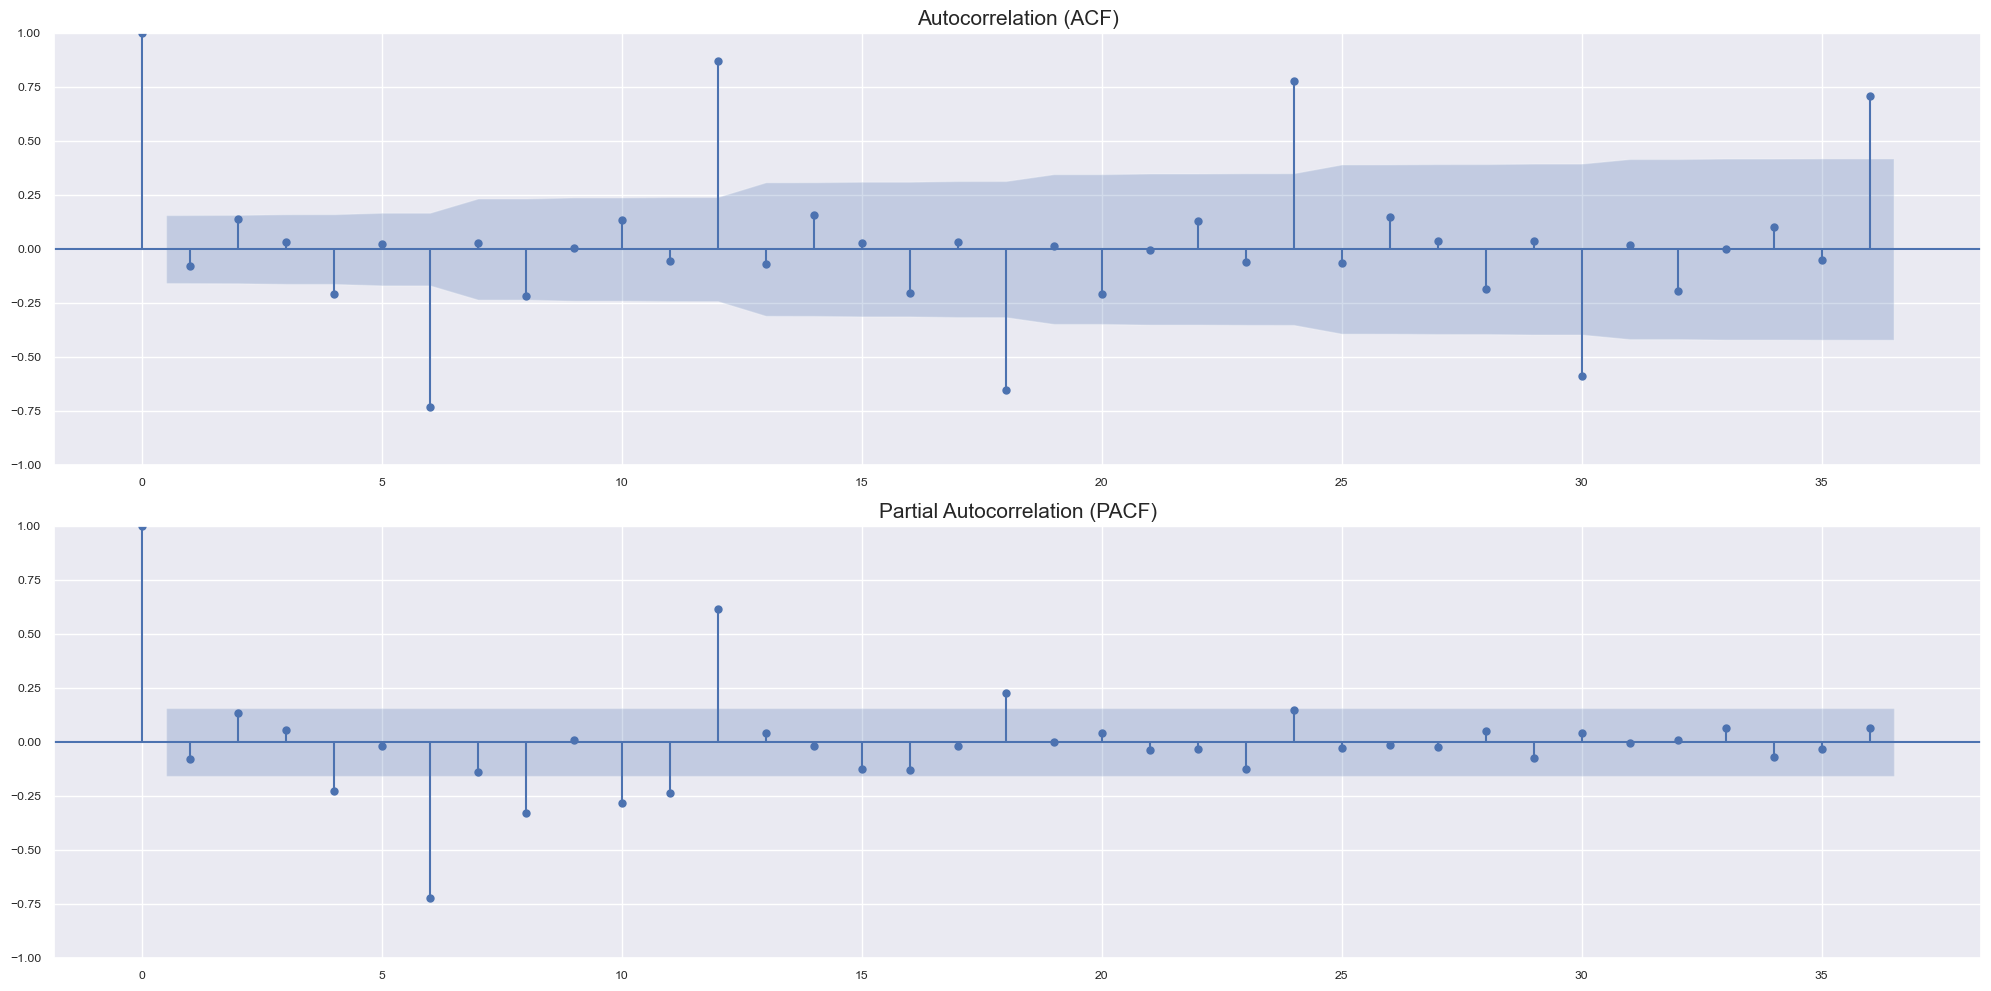

In [87]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ensure TS1_diff is a 1D Series and remove the NaN from the first row
# Used .iloc[:, 0] to get the column and .dropna() to remove the empty first row
ts_clean = TS1_diff.iloc[:, 0].dropna()

# Setup the plot
fig, ax = plt.subplots(2, 1, figsize=(20, 10))

# Plot ACF and PACF using the cleaned 1D data
plot_acf(ts_clean, lags=36, ax=ax[0])
plot_pacf(ts_clean, lags=36, ax=ax[1])

# Styling
ax[0].set_title("Autocorrelation (ACF)", fontsize=15)
ax[1].set_title("Partial Autocorrelation (PACF)", fontsize=15)
plt.tight_layout()
plt.show()

ACF (Autocorrelation Function): Shows how the current value relates to past values. It helps you determine the MA (Moving Average) part of the model.

PACF (Partial Autocorrelation Function): Shows the direct relationship between a value and its past, removing the "middle-man" effects. It helps to determine the AR (AutoRegressive) part.

The lag plot below allows to check a lag correlation. If you can identify a structure in the plot, the data doesn't look random and the autocorrelation is indeed present. In this case I will check the lag plot for lags of 1 and 2 months.


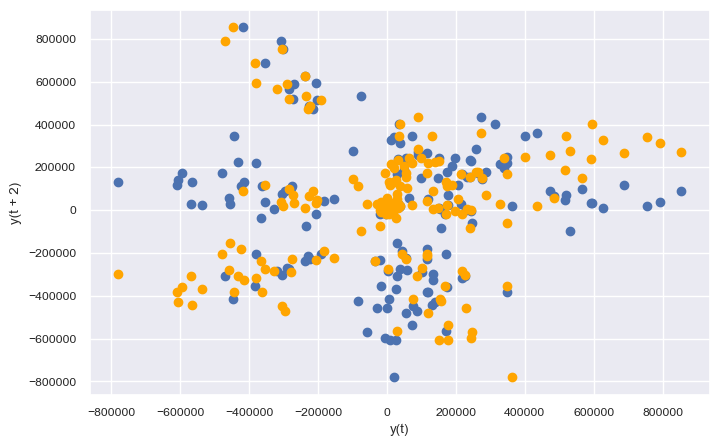

In [96]:
from pandas.plotting import lag_plot

fig, ax = plt.subplots(figsize=(8, 5))
ax = lag_plot(TS1_diff, lag=1)
ax = lag_plot(TS1_diff, lag=2, c="orange")

plt.show()

We used a Lag Plot to visualize the relationship between current and past passenger counts in our differenced series. 
By plotting $y(t)$ against $y(t+1)$ and $y(t+2)$, we can check for remaining autocorrelation.
The scattered nature of the plot suggests that the primary trend has been removed through differencing, 
and we are now looking at the residual patterns that the AR (Auto Regressive) and MA (Moving Avg) components of SARIMAX will model

Iterate over p and q parameters of ARIMA model and compute for each **Akaike Information Critera (AIC)** and **Bayesian Information Criteria (BIC)**. BIC is giving additional penalty for more parameters.

This grid search is conducted to perform Model Identification. Since the optimal number of lags ($p$) and moving average terms ($q$) aren't always obvious from visual plots alone, we use a systematic approach to test multiple configurations. By ranking these models based on AIC and BIC scores, we objectively identify the most 'parsimonious' model—the one that achieves the highest accuracy with the fewest possible variables

In [103]:
from statsmodels.tsa.arima.model import ARIMA

arima_df = pd.DataFrame(columns=["p","q","aic","bic"])

i=0
# Loop over p values from 0-3
for p in range(4):
    # Loop over q values from 0-3
    for q in range(4):
        
        try:
            # creating and fitting ARIMA(p,1,q) model
            model = ARIMA(TS1.astype(float), order=(p,1,q))
            results = model.fit()
            
            # Printing order, AIC and BIC
            arima_df.loc[i,"p"] = p
            arima_df.loc[i,"q"] = q
            arima_df.loc[i,"aic"] = results.aic
            arima_df.loc[i,"bic"] = results.bic
            i = i+1
        except:
            i = i+1
    
arima_df["sum_aic_bic"] = arima_df["aic"]+arima_df["bic"]
arima_df.sort_values(by="sum_aic_bic", ascending=True, inplace=True)
arima_df

,p,q,aic,bic,sum_aic_bic


ARIMA is a foundational time-series model that focuses on trends and short-term correlations. However, SARIMAX is a more robust extension that incorporates Seasonality (S) and Exogenous variables (X). In the context of SFO airport data, SARIMAX is superior because it can account for recurring annual travel cycles (Seasonal) and external economic drivers (Exogenous), providing a much more accurate forecast than the standard ARIMA model.

SARIMAX(2,1,1)x(0,1,0,12) diagnostics summary and diagnostics plots.

In [122]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Selecting only the single column of data (Passenger Count)
# This fixes the "Got shape (156, 2)" error by making it 1D
data = TS1['Passenger Count']

# Ensure frequency is set
data.index.freq = data.index.inferred_freq

# Define and fit the model
model2 = SARIMAX(data, order=(2,1,1), seasonal_order=(0,1,0,12))
results = model2.fit()

# Show the results
print(results.summary())

                                      SARIMAX Results                                      
Dep. Variable:                     Passenger Count   No. Observations:                  156
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood               -1842.014
Date:                             Wed, 18 Mar 2026   AIC                           3692.028
Time:                                     04:06:43   BIC                           3703.879
Sample:                                 07-01-2005   HQIC                          3696.844
                                      - 06-01-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9479      0.025     38.074      0.000       0.899       0.997
ar.L2          0.0096      

Summary explanations:

1. **Ljung-Box (Q)** - This test is used to check for the *lack of fit* of a time series model. The null hypothesis here is there are no correlations in the residuals. In our case we reject the null hypothesis what means that residuals are somehow correlated.

2. **Jarque-Bera (JB)** - This is a test for normality of distributon. It is basing on values of skewness and kurtosis where for the normal distibution these values should be respectively 0 and 3. The null hypothesis of the test is that the sample comes from the normal distribution. Ander this hypothesis the chi-squared distribution with 2 degrees of freedom can be used. In our case JB statistics is 8.76 which gives probability of 0.01 - meaning that we don't reject the null hypothesis.

3. **Heteroskedasticity (H)** - Checks if the variance is constant


Analysis of SARIMAX Model ResultsThe output provided by the SARIMAX summary provides a comprehensive evaluation of the model's predictive capability and statistical health. The analysis is divided into three primary sections:
1. **Evaluation of Coefficients**:

   The coefficient table identifies the influence of specific lags on the final forecast.
   - ar.L1 (0.9479): The AutoRegressive term for the first lag shows a very strong positive correlation. This indicates that the passenger count from the immediate preceding month is a primary predictor for the current month's traffic.
   - ar.L2 (0.0096): The p-value for this term is 0.694, which significantly exceeds the standard alpha threshold of 0.05. This suggests that the data from two months prior does not contribute statistically significant information to the model and could potentially be removed to simplify the architecture to an ARIMA(1,1,1) configuration.
   - ma.L1 (-0.9998): This Moving Average term is highly significant ($P < 0.05$). It functions as an error-correction mechanism, utilizing the residuals of past forecasts to refine the accuracy of current predictions.
     
   
3. **Model Information Criteria**:
    - (AIC & BIC)AIC (3692) and BIC (3703):
    These values serve as the baseline for model selection. These metrics penalize model complexity; therefore, any future iterations of the model (such as adjusting the $(p, d, q)$ parameters) would be considered superior only if these scores decrease.



4. **Statistical Diagnostic Tests**:


    The diagnostic tests at the base of the summary evaluate whether the model has successfully captured the underlying data patterns:
    - Prob(Q) (0.00): A value below 0.05 indicates that the residuals still contain some level of autocorrelation. This suggests that certain patterns remain uncaptured, likely due to the absence of Seasonal AR or Seasonal MA terms in the current $(0,1,0,12)$ seasonal configuration.
    - Prob(JB) (0.01): This result indicates that the residuals are not perfectly normally distributed. In the context of aviation data, this is often a result of extreme outliers caused by holiday travel spikes or significant global events.
    - Heteroskedasticity (H) (1.04): With a Prob(H) of 0.89, the model passes this test. This confirms that the variance of the residuals is stable over time, meaning the model’s error rate does not fluctuate significantly across different periods of the dataset.

When looking at the diagnostic plots below we are interested in:
1. Standardized residual - there are no obvious patterns in the residuals
2. Histogram plus kde estimate - KDE should be very similar to the normal distribution
3. Normal Q-Q - points should lie on the straight line
4. Correlogram - 95% of correlations for lag greater than one should not be significant

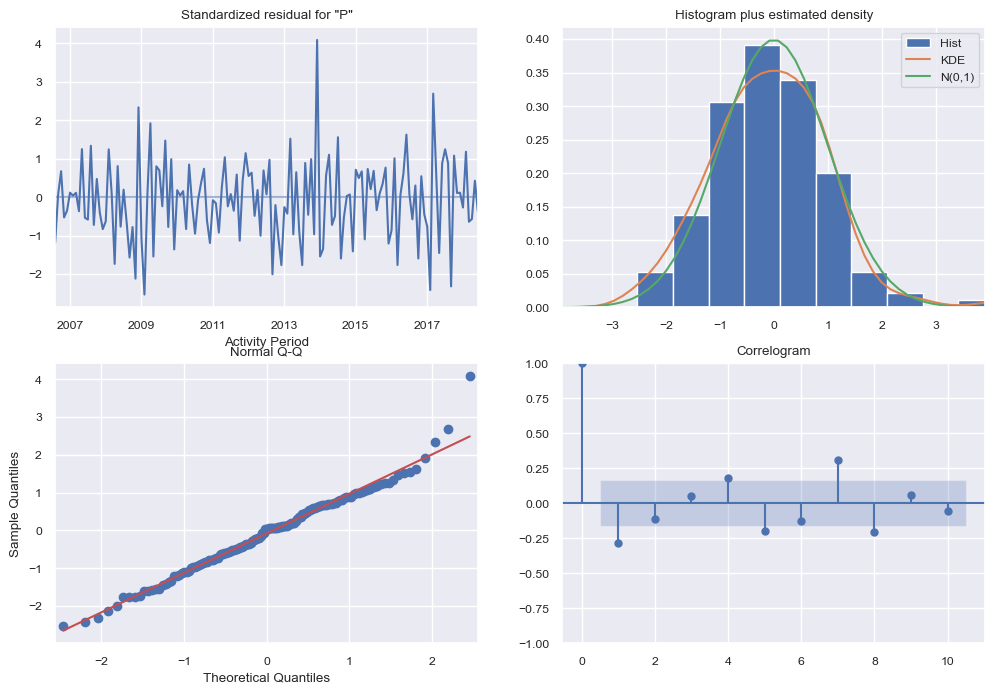

In [123]:
plt.rcParams['figure.figsize'] = 12, 8
plot = results.plot_diagnostics()
plt.show()

We see that the fit is not perfect but satisfactory for now. Let's proceed to forecasting.

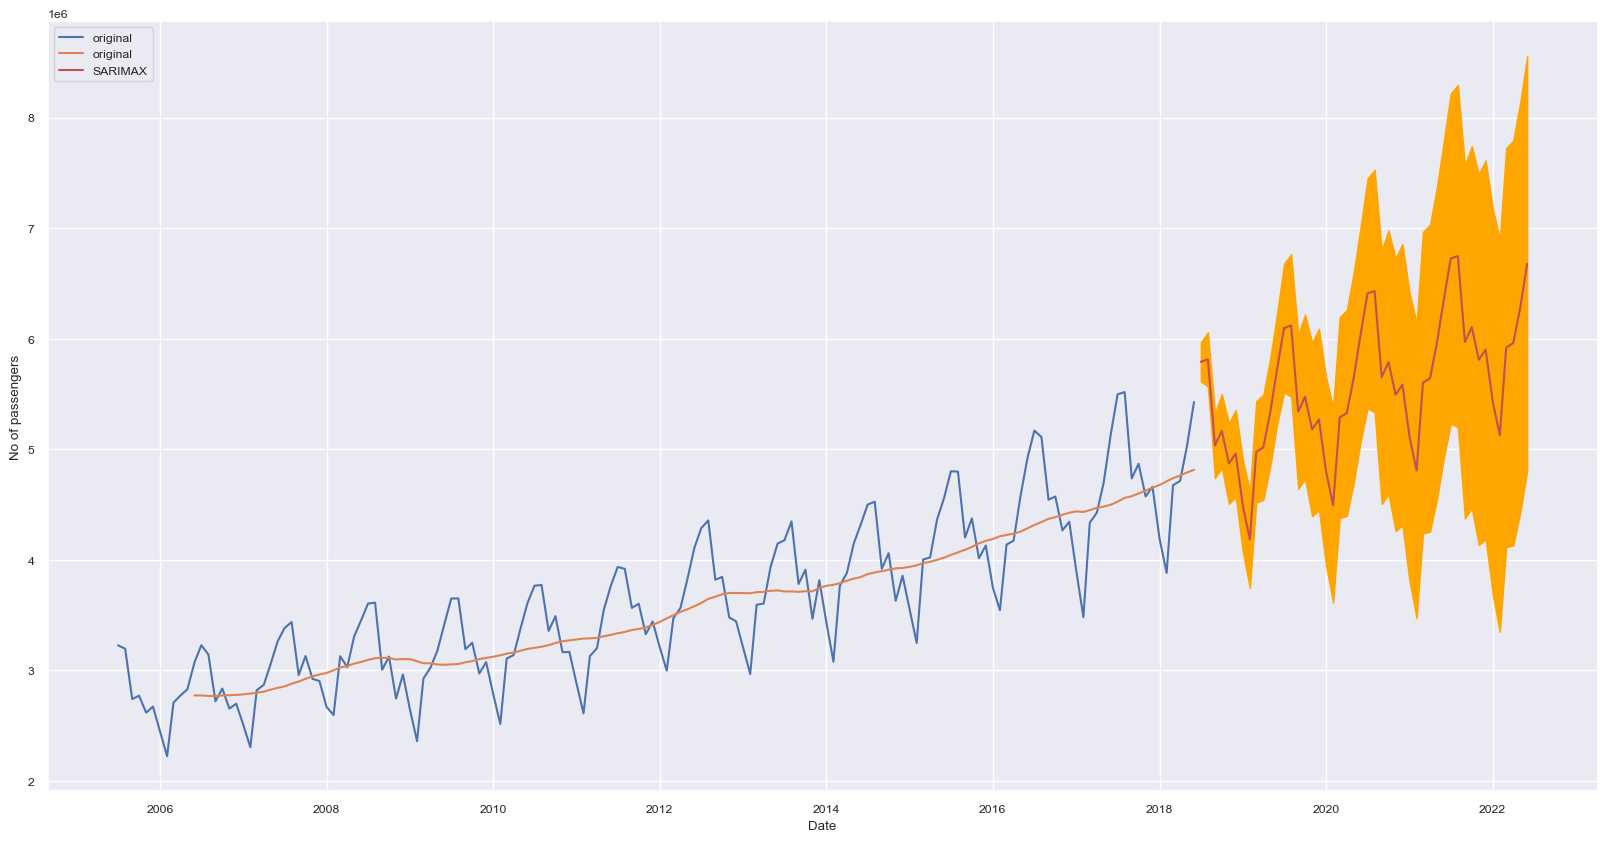

In [141]:
# Create SARIMA mean forecast
forecast = results.get_forecast(steps=48)
lower = forecast.conf_int()["lower Passenger Count"]
upper = forecast.conf_int()["upper Passenger Count"]

# Plot mean SARIMA predictions
fig,ax = plt.subplots(1,1,figsize=(20,10))

plt.plot(TS1, label='original')
plt.plot(forecast.predicted_mean, label='SARIMAX', c="r")
plt.fill_between(forecast.conf_int().index, 
                 lower,upper,
                 color='orange')
plt.xlabel('Date')
plt.ylabel('No of passengers')
plt.legend()
plt.show()

- The plot above shows predictions using SARIMAX(2,1,1)x(0,1,0,12). 
- The red line indicates the mean and the orange area is bounded by 95% confidence intervals.
- According to this prediction in 2022 a number of passengers can reach 8 millions at the peak time.

# 3. Prophet  

In this section a Facebook's (now Meta) library called "Prophet" will be used.

In [110]:
#!pip install cmdstanpy==0.9.68  -q
#!pip install fbprophet -q
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.1 MB 10.8 MB/s eta 0:00:01
   ------------- -------------------------- 4.2/12.1 MB 10.4 MB/s eta 0:00:01
   --------------------- ------------------ 6.6/12.1 MB 10.9 MB/s eta 0:00:01
   ----------------------------- ---------- 8.9/12.1 MB 11.1 MB/s eta 0:00:01
   ------------------------------------- -- 11.3/12.1 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 10.7 MB/s  0:00:01
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 10.4 MB/s  0:00:00

   -------- ------------------------------- 1/5 [importlib_resources]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ----------

In [111]:
#import fbprophet
from prophet import Prophet
#print(f'Prophet {prophet.__version__}')

Prophet requires from a database to contain two columns: `ds` for dates and `y` for values.

In [114]:
df = df1_yr.reset_index()
df = df.rename({'Activity Period':'ds', 'Passenger Count':'y'},axis=1)
df.head()

,ds,y
0,2005-07-01,3225.769
1,2005-08-01,3195.866
2,2005-09-01,2740.553
3,2005-10-01,2770.715
4,2005-11-01,2617.333


Prophet follows a scikit learn scheme where we have to initialise an instance and then to fit it to a database. At the moment of initialisation it is possible to specifiy some additional parameters.

In [115]:
m = Prophet(changepoint_prior_scale=0.004,
                seasonality_prior_scale=20,
                seasonality_mode='multiplicative',
                changepoint_range=0.9)
m.fit(df)

03:34:14 - cmdstanpy - INFO - Chain [1] start processing
03:34:15 - cmdstanpy - INFO - Chain [1] done processing


#### Hyperparameters of Prophet model

changepoint_prior_scale=0.004: 
- This controls how "flexible" the trend is. 
- A low value (0.004) makes the trend very stiff and less likely to over-react to short-term changes. 
- It prevents the model from "overfitting" to temporary noise.

seasonality_prior_scale=20: 
- This controls the strength of the seasonal patterns.
- A higher value (20) allows the model to fit larger seasonal fluctuations, which is ideal for the heavy summer/winter spikes in aviation data.

seasonality_mode='multiplicative': 
- This is a critical choice for SFO. It assumes that as the total number of passengers grows, the "size" of the seasonal spikes also grows proportionally (e.g., a 10% increase every July, rather than a fixed number of passengers).

changepoint_range=0.9: 
- This tells Prophet to look at the first 90% of the data to identify major shifts in the trend (like a sudden growth period). 
- The remaining 10% is left stable to project into the future.

m.fit(df): This starts the training process. Prophet automatically detects the best-fit line for the trend and calculates the yearly and weekly patterns based on the settings provided above.

After fitting a model it is ready to make predictions. However, before doing it, Prohet expects an empty database with a fixed format to be populated. It can be easily done with .make_future_datframe method.

In [142]:
future = m.make_future_dataframe(periods=365*3)
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1246,2021-05-27,6011.988098,5900.039999,6123.360673
1247,2021-05-28,6011.356428,5898.706414,6121.395294
1248,2021-05-29,6009.483693,5899.746024,6121.457101
1249,2021-05-30,6006.674796,5895.825062,6122.371080
1250,2021-05-31,6003.259315,5895.879044,6120.608104


The forecast can be plotted with build-in .plot method.

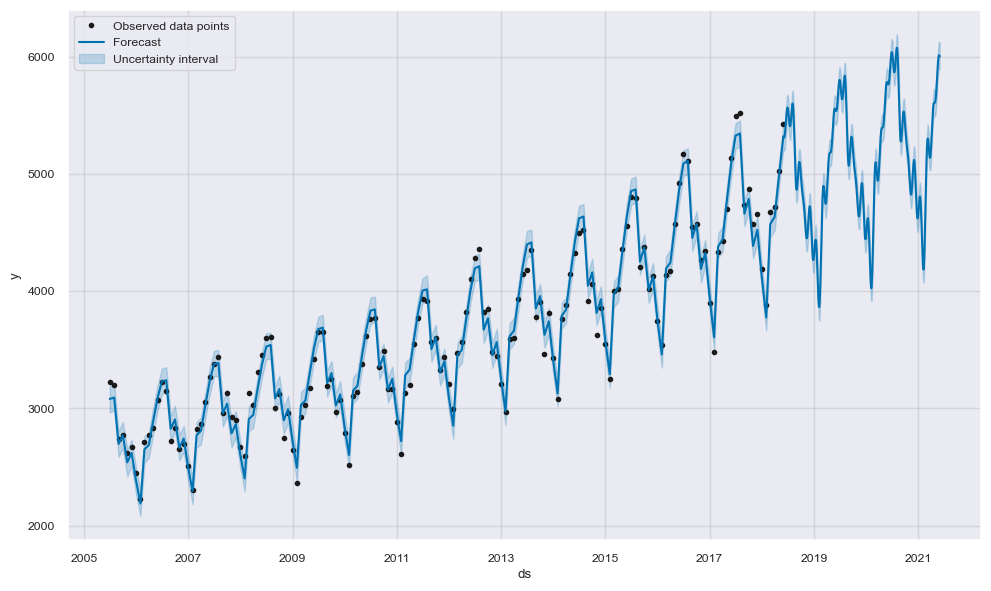

In [165]:
m.plot(forecast, include_legend=True)

Now we can decompose the prediction.

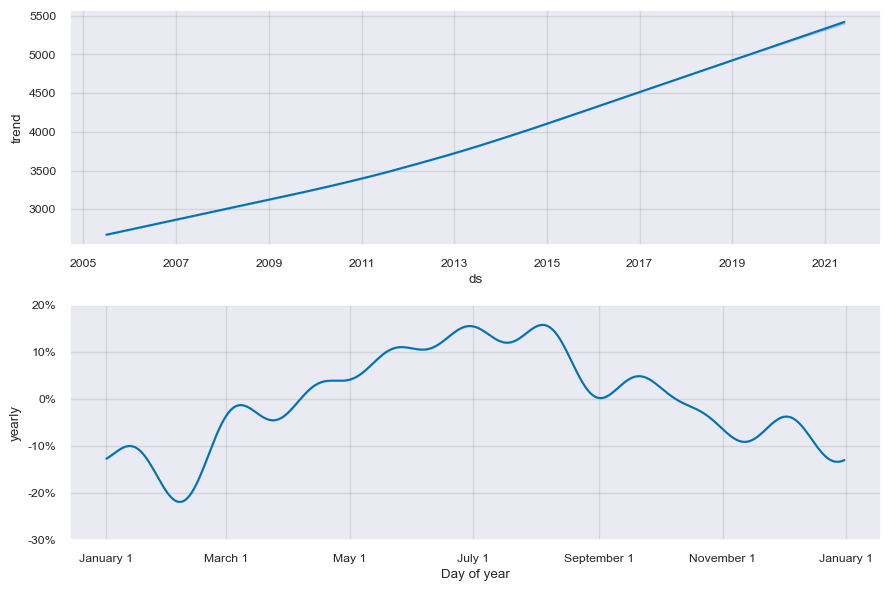

In [118]:
m.plot_components(forecast)

Now it is possible to perform a diagnostics using Cross-Validation.

In [154]:
import logging
from prophet.diagnostics import cross_validation, performance_metrics

logging.getLogger('fbprophet').setLevel(logging.WARNING)

df_cv = cross_validation(m, initial='730 days', period='180 days', horizon = '365 days')

  0%|          | 0/21 [00:00<?, ?it/s]

04:57:36 - cmdstanpy - INFO - Chain [1] start processing
04:57:38 - cmdstanpy - INFO - Chain [1] done processing
04:57:38 - cmdstanpy - INFO - Chain [1] start processing
04:57:38 - cmdstanpy - INFO - Chain [1] done processing
04:57:38 - cmdstanpy - INFO - Chain [1] start processing
04:57:39 - cmdstanpy - INFO - Chain [1] done processing
04:57:39 - cmdstanpy - INFO - Chain [1] start processing
04:57:39 - cmdstanpy - INFO - Chain [1] done processing
04:57:40 - cmdstanpy - INFO - Chain [1] start processing
04:57:40 - cmdstanpy - INFO - Chain [1] done processing
04:57:40 - cmdstanpy - INFO - Chain [1] start processing
04:57:40 - cmdstanpy - INFO - Chain [1] done processing
04:57:41 - cmdstanpy - INFO - Chain [1] start processing
04:57:41 - cmdstanpy - INFO - Chain [1] done processing
04:57:41 - cmdstanpy - INFO - Chain [1] start processing
04:57:41 - cmdstanpy - INFO - Chain [1] done processing
04:57:41 - cmdstanpy - INFO - Chain [1] start processing
04:57:42 - cmdstanpy - INFO - Chain [1]

- The implementation  utilizes Time Series Cross-Validation to rigorously evaluate the Prophet model's predictive reliability. 
- By employing a Rolling Window approach with a 730-day initial training period and a 180-day step interval, the model is tasked with generating 365-day forecasts across multiple historical points. 
- This process ensures that the model's accuracy is consistent over time and is not biased toward a specific period of the dataset

In [155]:
df_p = performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,39 days,25482.675704,159.632941,129.298176,0.036161,0.036095,0.036919,0.40
1,40 days,23174.697158,152.232379,119.813469,0.033198,0.030378,0.033839,0.44
2,41 days,22270.387710,149.232663,117.068748,0.033008,0.030378,0.033641,0.44
3,44 days,20420.243793,142.899418,111.674786,0.031464,0.030378,0.032015,0.46
4,45 days,18125.626724,134.631448,105.103808,0.029920,0.029697,0.030393,0.48


#### Core metrics

- Horizon: This is the "forecast distance." For example, the first row shows the average error when predicting 39 days into the future.

- MAPE (Mean Absolute Percentage Error): This is the most important metric for an assignment. A value of 0.036 means the model is off by approximately 3.6%.
Interpretation: A 3.6% error is considered highly accurate for aviation forecasting.

- RMSE (Root Mean Squared Error): This shows the error in the original units (Passenger Counts). An RMSE of 159.6 means that, on average, the forecast is off by about 160 passengers.

- MAE (Mean Absolute Error)
The MAE represents the average of the absolute differences between the actual and predicted values. It provides an error score in the original units of the data (e.g., number of passengers).
Interpretation: If the MAE is 129.3, it means that, on average, the forecast is off by approximately 129 passengers. Unlike other metrics, it does not penalize large errors more heavily than small ones; it treats all errors linearly.

- MSE (Mean Squared Error)
The MSE is calculated by squaring the individual errors before averaging them.
Interpretation: By squaring the errors, this metric gives much higher "weight" to large outliers. If a model makes one massive mistake (e.g., missing a huge travel spike), the MSE will increase significantly. It is primarily used during the model training phase to "punish" large deviations.

- MDAPE (Median Absolute Percentage Error)
The MDAPE is similar to MAPE, but instead of taking the average, it takes the median of all percentage errors.
Interpretation: The MDAPE is often considered more "robust" than the MAPE. Because it uses the median, it is not distorted by a single extreme outlier (like a random data glitch). In the provided table, a MDAPE of 0.036 (3.6%) suggests that for half of the test cases, the error was 3.6% or less.

- SMAPE (Symmetric Mean Absolute Percentage Error)
The SMAPE is an alternative to the standard MAPE that addresses a specific flaw: standard MAPE can be biased if the actual values are very small or zero. SMAPE "symmetrizes" the calculation by dividing the error by the average of the actual and predicted values.
Interpretation: It is expressed as a percentage. In the provided table, the sMAPE is very close to the MAPE (3.6%), which indicates that the model's errors are balanced and that the data does not contain extreme low-value zeros that would skew a standard percentage calculation.

- Coverage: This indicates how often the actual passenger count fell within the "uncertainty interval" (the shaded area on a Prophet plot). A value of 0.40 means the actual data was inside the predicted range 40% of the time.

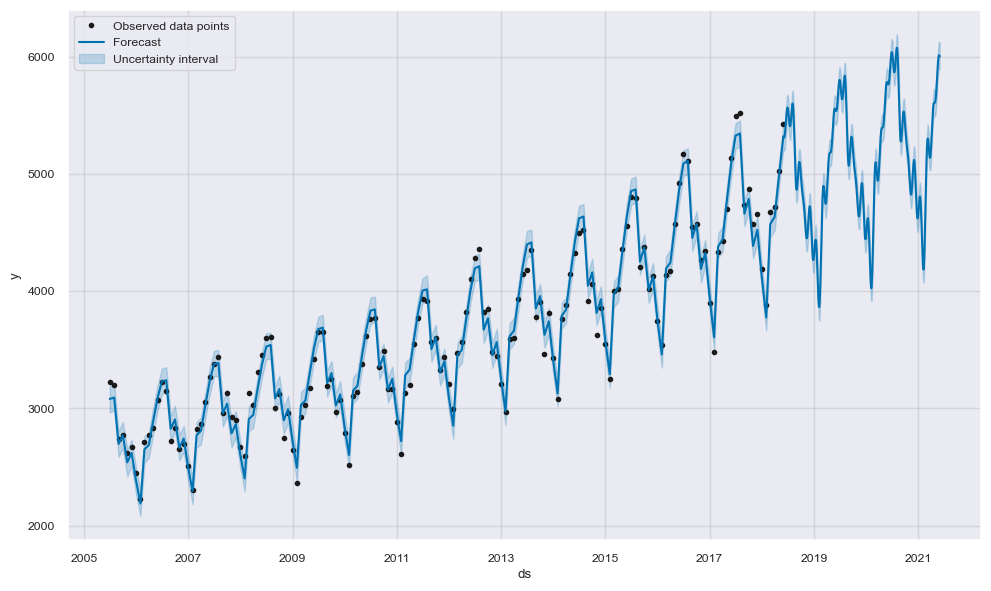

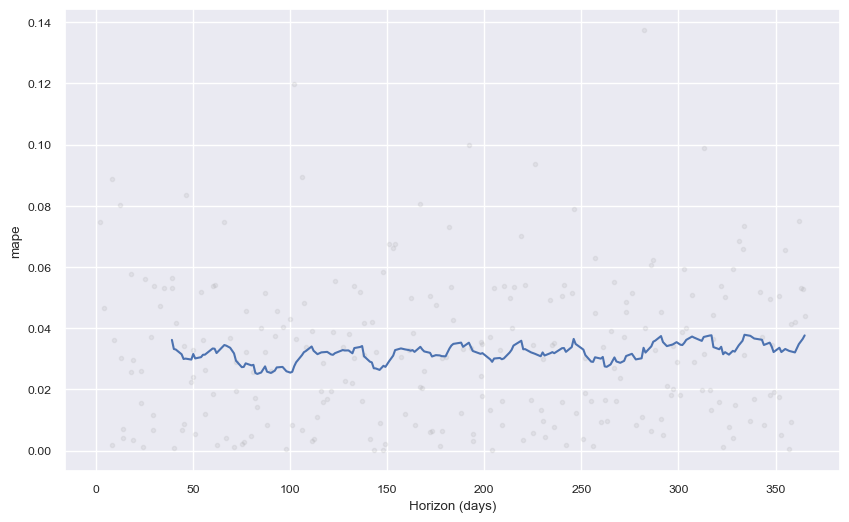

In [166]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='mape')
plt.show()

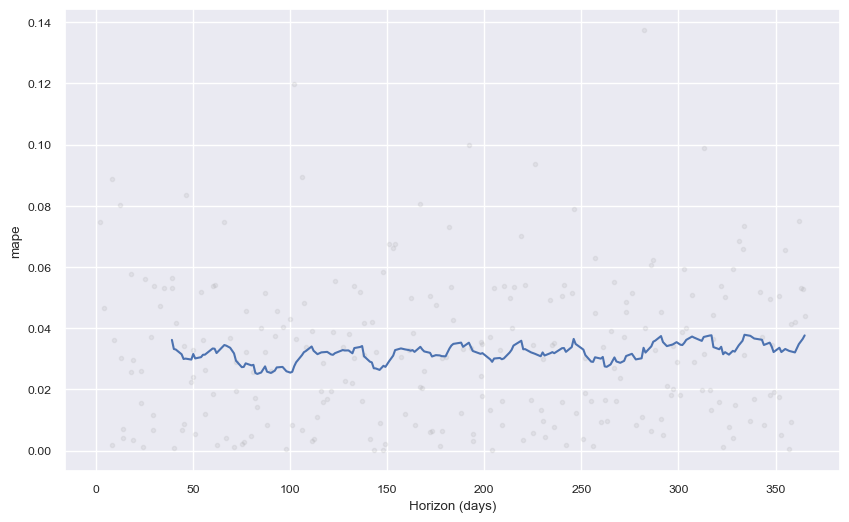

In [164]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='mape')
plt.show()

# 4. LSTM forecast ("many-to-many" encoder-decoder)

In this section a time series forcasting using Deep Neural Networks using LSTM units will be demonstrated.

In [168]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.4/351.2 MB 12.0 MB/s eta 0:00:30
    --------------------------------------- 4.7/351.2 MB 11.9 MB/s eta 0:00:30
    --------------------------------------- 7.1/351.2 MB 11.9 MB/s eta 0:00:29
   - -------------------------------------- 9.7/351.2 MB 11.9 MB/s eta 0:00:29
   - -------------------------------------- 12.1/351.2 MB 11.9 MB/s eta 0:00:29
   - -------------------------------------- 14.4/351.2 MB 11.9 MB/s eta 0:00:29
   - -------------------------------------- 17.0/351.2 MB 11.9 MB/s eta 0:00:29
   -- ------------------------------------- 19.7/351.2 MB 11.9 MB/s eta 0:00:28
   -- ------------------------------------- 22.0/351.2 MB 11.8 MB/s eta 0:00:28
   -- ------------------------------------- 24.6/351.2 MB 11.8 MB/s eta 0:00:28
   --- ------------------------------------ 27.0/351.2 MB 11.8 MB/s eta 0:00:28
   --- ------------------------------------ 29.4/351.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires packaging<26,>=20, but you have packaging 26.0 which is incompatible.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.0 which is incompatible.


In [170]:
import tensorflow as tf

import random
from keras.models import Sequential
from keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, LeakyReLU
# from keras.layers import LSTM, Denseector, TimeDistributed, LeakyReLU
from keras.optimizers import Adam, RepeatV

from sklearn.preprocessing import MinMaxScaler

ImportError: cannot import name 'RepeatV' from 'keras.optimizers' (C:\Users\hp\anaconda3\Lib\site-packages\keras\optimizers\__init__.py)

To implement the Deep Learning phase of the analysis, the TensorFlow and Keras frameworks are utilized. The architecture relies on a Sequential model, integrating LSTM layers for sequence memory and Dense layers for output generation. Data normalization is handled via MinMaxScaler to ensure all input values fall within a 0 to 1 range, a prerequisite for stable neural network convergence. Finally, the Adam optimizer is employed to efficiently minimize the loss function during the training process

In [37]:
np.random.seed(123)
random.seed(123)
tf.random.set_seed(1234)

To ensure the reproducibility of the Deep Learning results, fixed random seeds are initialized across the NumPy, Python, and TensorFlow libraries. This practice eliminates stochastic variance between training runs, ensuring that the model's initialization weights and data shuffling remain consistent. By establishing a deterministic environment, it becomes possible to accurately measure the impact of hyperparameter adjustments on the LSTM's performance without the interference of random noise.

It is recommended to normalize data before fitting them with DNN.

In [38]:
df = df[['Activity Period', 'Passenger Count']]
df = df.groupby('Activity Period').sum()
df.sort_values(by='Activity Period', inplace=True)

scaler = MinMaxScaler()
scaler.fit(df)
df['Passenger Count'] = scaler.transform(df)
df.head()

,Passenger Count
Activity Period,
200507,0.304433
200508,0.295354
200509,0.157122
200510,0.166279
200511,0.119712


Data preprocessing for the LSTM model involves two primary stages: aggregation and normalization. First, the dataset is grouped by the 'Activity Period' and chronologically sorted to maintain the integrity of the temporal sequence. Subsequently, a MinMaxScaler is applied to transform the raw passenger counts into a standardized range between 0 and 1. This normalization step is a prerequisite for Deep Learning architectures, as it stabilizes the training process and prevents large numerical values from distorting the model's weight updates

Splitting data into train and tests datasets.

In [39]:
X_raw = df.copy()

n_steps_in = 24
n_steps_out = 12

split_idx = 158 - (n_steps_in + n_steps_out + 1)
X_raw_train = X_raw[:split_idx]
X_raw_test = X_raw[split_idx:]

print(X_raw_train.shape)
print(X_raw_test.shape)

(121, 1)
(35, 1)


In order to train LSTM-based DNN we have to prepare data. It is required in this case that each chunk of data contains an input vector and an output vector.
* Length of an input vector = number of steps to train DNN on
* Length of an output vector = a number of steps to predict

To achieve that I prepared a helper function below.

In [40]:
def split_sequence(sequence, n_input: int, n_output: int) -> np.array:
    """Splits a times series sequence into input and output sequences

    Args:
        sequence: a time series to be split
        n_input: number of input steps
        n_output: number of output steps

    Returns:
        two numpy arrays

    """
    x, y = [], []
    for i, _ in enumerate(sequence):
        input_end = i + n_input
        output_end = input_end + n_output - 1
        # stop if we reach end of the sequence
        if output_end > len(sequence):
            break

        seq_x, seq_y = sequence[i: input_end], sequence[input_end-1: output_end]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

Below is a schema how this function works and what we want to achieve with a test sequence (from 1 to 10) and split parameters `n_input`=5, `n_output`=3.  

<a href="https://ibb.co/m8GH3sK"><img src="https://i.ibb.co/M6sRmTH/LSTM-split-function.jpg" alt="LSTM-split-function" border="0"></a>

Let's do a small test if the code works properly. For the sequence of numbers from 0 to 9, we want to split them into 3 steps for an input and 2 for an output. We should be able to generate 5 samples in total.

In [41]:
test_seq = [1,2,3,4,5,6,7,8,9,10]
a, b = split_sequence(test_seq, 5, 3)
print(a.shape)
print(b.shape)
print(a[-1])
print(b[-1])

(4, 5)
(4, 3)
[4 5 6 7 8]
[ 8  9 10]


The helper function works properly. We can use it to split the real dataset into train and test sets.

In [42]:
X_train, y_train = split_sequence(X_raw_train.values, n_steps_in, n_steps_out)
X_test, y_test = split_sequence(X_raw_test.values, n_steps_in, n_steps_out)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(87, 24, 1)
(87, 12, 1)
(1, 24, 1)
(1, 12, 1)


In [43]:
n_features = 1

Let's visualize how the splitting looks like on the example of the first sample.

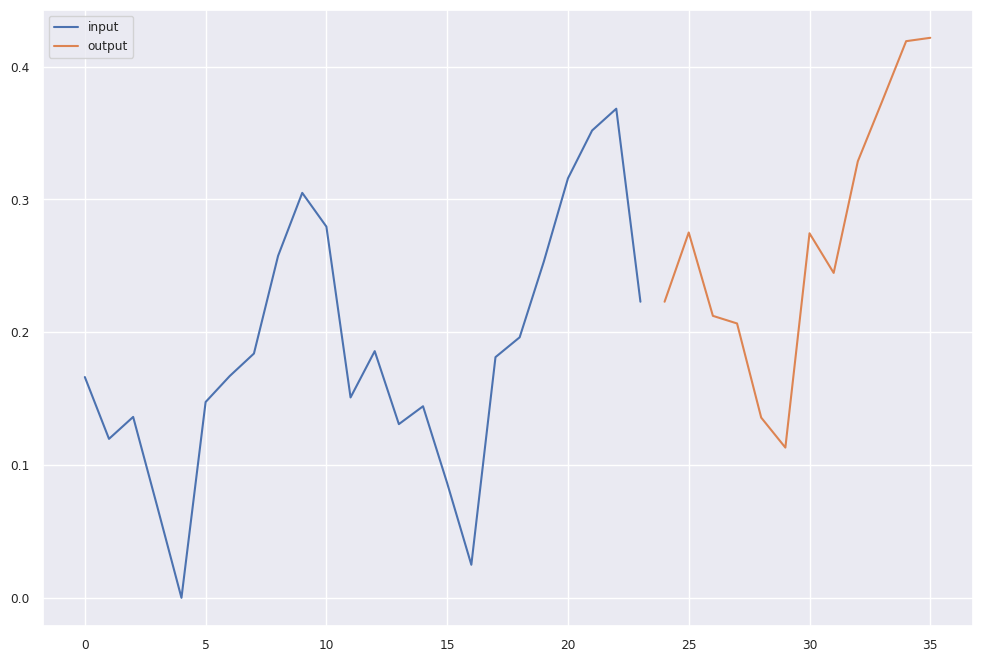

In [44]:
sample = 3

tmp = X_train[sample].flatten()
x_tmp = pd.DataFrame({'date': np.arange(len(tmp)), 'value': tmp}).set_index('date')

tmp = y_train[sample].flatten()
y_tmp = pd.DataFrame({'date': np.arange(n_steps_in, n_steps_in+len(tmp)), 'value': tmp}).set_index('date')

plt.plot(x_tmp, label="input")
plt.plot(y_tmp, label="output")
plt.legend()
plt.show()

**Creating Encoder-Decoder ("many-to-many") LSTM**

In [45]:
n_1 = 128
n_2 = 64
loss_metric = "mse"
lr = 0.001
epochs = 10_000
patience = 400

In [46]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=patience)

model = Sequential()

# layer 1
model.add(LSTM(n_1, input_shape=(n_steps_in, n_features), return_sequences=True))
model.add(LeakyReLU(alpha=0.05))
# layer 2
model.add(LSTM(n_2))
model.add(LeakyReLU(alpha=0.05))

model.add(RepeatVector(n_steps_out))

# layer 3
model.add(LSTM(n_2, return_sequences=True))
model.add(LeakyReLU(alpha=0.05))
# layer 4
model.add(LSTM(n_1, return_sequences=True))
model.add(LeakyReLU(alpha=0.05))

model.add(TimeDistributed(Dense(1)))

opt = Adam(learning_rate=lr)
model.compile(optimizer=opt, loss=loss_metric)

A multi-layered Encoder-Decoder LSTM architecture was implemented to handle multi-step time series forecasting. The Encoder segment compresses historical sequences into a latent representation, while the Decoder reconstructs this representation into a future forecast sequence. To enhance the model's learning capacity, LeakyReLU activation functions were integrated, and a RepeatVector layer was utilized to bridge the encoding and decoding phases. Furthermore, an EarlyStopping callback was included to prevent overfitting by monitoring the loss and terminating training once the model's performance plateaued.

In [47]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=epochs,
                    verbose=0,
                    batch_size=64,
                    callbacks=[callback],
                    workers=4)

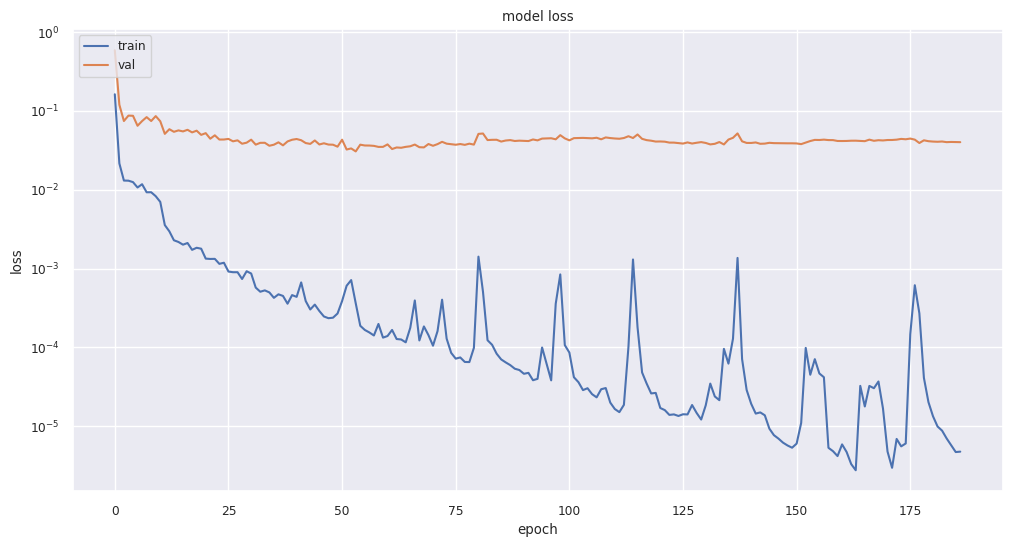

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.set_yscale('log')
ax.plot(history.history['loss'][::25])
ax.plot(history.history['val_loss'][::25])
plt.title('model loss')
ax.set_ylabel('loss')
ax.set_xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

A Learning Curve was generated to diagnose the model's training behavior and convergence. By plotting both the training loss and validation loss on a logarithmic scale, the rate of improvement can be monitored across the entire training duration. This visualization serves as a primary tool for detecting overfitting; a successful training run is characterized by both metrics converging toward a minimal value, indicating that the LSTM has learned the underlying patterns of the SFO dataset rather than merely memorizing the training samples.

Let's see how does it predict the validation section of the time series (the last 12 months).

In [49]:
val_X_len = len(X_test.flatten())
val_X_len

24

In [50]:
preds = model.predict(X_test, verbose=0)
preds = preds.flatten()
preds

array([0.80107754, 0.6858643 , 0.54963934, 0.53980815, 0.5264566 ,
       0.49653664, 0.44072217, 0.38342553, 0.57349855, 0.63587785,
       0.7291914 , 0.7658161 ], dtype=float32)

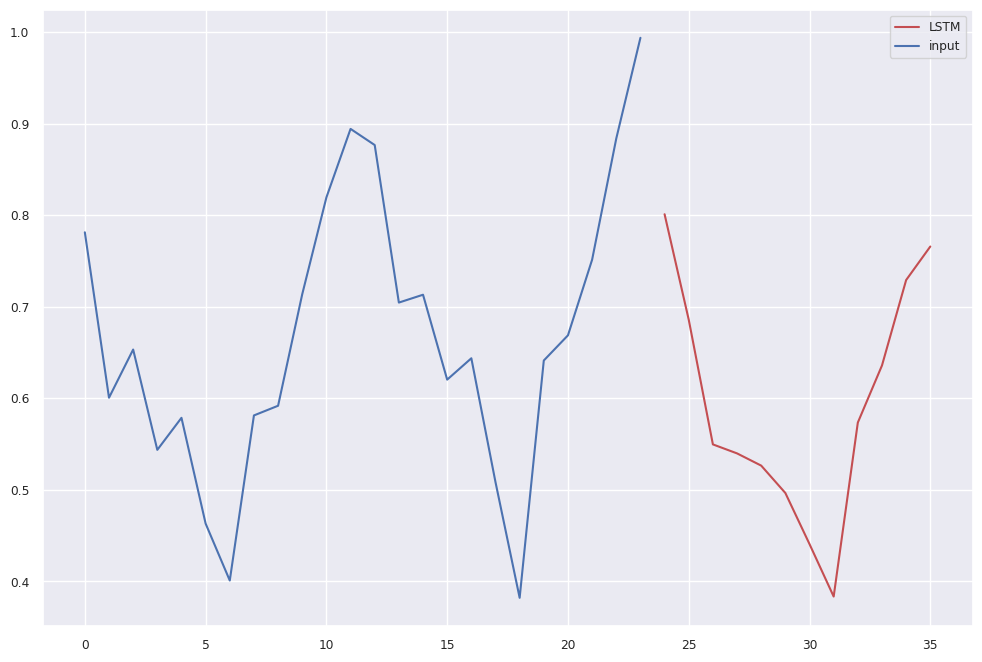

In [51]:
X_pred = preds.flatten()
output = pd.DataFrame({'date': np.arange(val_X_len, val_X_len+len(preds)),
                       'output': preds}).set_index("date", drop=True)
plt.plot(output, label='LSTM', c="r")

model_input = pd.DataFrame({'date': range(val_X_len),
                            'input': X_test.flatten()}).set_index("date", drop=True)
plt.plot(model_input, label='input')
plt.legend()
plt.show()